# Exploración — anexo EMICRON: panaderías y tiendas de barrio, 2024

Este notebook explora exclusivamente el archivo `anex-EMICRON-PanaderiasTiendasBarrio-2024.xlsb`. Primero inventaría todas sus hojas y luego permite examinar una tabla a la vez.

## 1. Cargar el libro

El archivo está en formato Excel binario (`.xlsb`) y se lee con `pyxlsb`. Los datos originales no se modifican.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display
import subprocess

PROJECT_DIR = Path.cwd().resolve().parent
FILE_PATH = PROJECT_DIR / 'data' / 'raw' / 'anex-EMICRON-PanaderiasTiendasBarrio-2024.xlsb'

subprocess.check_call(['pip', 'install', 'pyxlsb'])

workbook = pd.ExcelFile(FILE_PATH, engine='pyxlsb')
SHEETS = workbook.sheet_names

print(f'Archivo: {FILE_PATH.name}')
print(f'Hojas encontradas: {len(SHEETS)}')
print(SHEETS)

Archivo: anex-EMICRON-PanaderiasTiendasBarrio-2024.xlsb
Hojas encontradas: 40
['Índice', 'Índice ', 'A.1', 'A.2', 'B.1', 'B.2', 'C.1', 'C.2', 'C.3', 'C.4', 'D.1', 'D.2', 'D.3', 'E.1.1', 'E.1.2', 'E.2', 'E.3', 'E.3.1.1', 'E.3.1.2', 'E.3.1.3', 'F.1', 'F.2', 'F.3', 'F.4', 'F.5', 'G.1', 'G.2', 'G.3', 'G.4', 'H.1', 'H.2', 'H.3', 'H.4', 'H.5', 'H.6', 'H.7', 'H.8', 'H.9', 'J.1', 'J.1_Errores']


## 2. Inventario de hojas

Las tablas se leen sin asumir encabezados: los anexos estadísticos suelen incluir títulos, notas y encabezados en varias filas.

In [ ]:
inventory = []

for sheet_name in SHEETS:
    sheet = pd.read_excel(FILE_PATH, sheet_name=sheet_name, header=None, engine='pyxlsb')
    non_empty = sheet.notna().sum().sum()
    first_values = sheet.stack().head(3).astype(str).tolist()
    inventory.append({
        'hoja': sheet_name,
        'filas': sheet.shape[0],
        'columnas': sheet.shape[1],
        'celdas_no_vacias': non_empty,
        'vista_previa': ' | '.join(first_values),
    })

inventory_df = pd.DataFrame(inventory)
display(inventory_df)

,hoja,filas,columnas,celdas_no_vacias,vista_previa
0,Índice,51,2,31,ENCUESTA DE MICRONEGOCIOS - VENDEDOR AMBULANTE...
1,Índice,64,2,56,ENCUESTA DE MICRONEGOCIOS - PANADERÍAS Y TIEN...
2,A.1,39,43,357,ENCUESTA DE MICRONEGOCIOS -PANADERÍAS Y TIENDA...
3,A.2,37,43,357,ENCUESTA DE MICRONEGOCIOS -PANADERÍAS Y TIENDA...
4,B.1,44,43,446,ENCUESTA DE MICRONEGOCIOS -PANADERÍAS Y TIENDA...
5,B.2,62,43,968,ENCUESTA DE MICRONEGOCIOS -PANADERÍAS Y TIENDA...
6,C.1,46,43,702,ENCUESTA DE MICRONEGOCIOS -PANADERÍAS Y TIENDA...
7,C.2,49,43,788,ENCUESTA DE MICRONEGOCIOS -PANADERÍAS Y TIENDA...
8,C.3,44,43,615,ENCUESTA DE MICRONEGOCIOS -PANADERÍAS Y TIENDA...
9,C.4,52,43,874,ENCUESTA DE MICRONEGOCIOS -PANADERÍAS Y TIENDA...


## 3. Explorar una tabla

Cambie `SHEET_TO_EXPLORE` para revisar otra hoja del inventario. La lectura conserva títulos y notas para poder identificar después la fila correcta de encabezados.

In [ ]:
SHEET_TO_EXPLORE = 'A.1'

if SHEET_TO_EXPLORE not in SHEETS:
    raise ValueError(f'La hoja {SHEET_TO_EXPLORE!r} no existe. Opciones: {SHEETS}')

df = pd.read_excel(FILE_PATH, sheet_name=SHEET_TO_EXPLORE, header=None, engine='pyxlsb')

print(f'Hoja: {SHEET_TO_EXPLORE}')
print(f'df.shape: {df.shape}')
print('\ndf.columns:')
print(df.columns.tolist())
print('\ndf.dtypes:')
display(df.dtypes.to_frame(name='dtype'))
print('\ndf.head(12):')
display(df.head(12))
print('\ndf.info():')
df.info()

missingness = pd.DataFrame({
    'valores_faltantes': df.isna().sum(),
    'porcentaje_faltante': (df.isna().mean() * 100).round(2),
})
print('\ndf.isna().sum():')
display(missingness)

Hoja: A.1
df.shape: (39, 43)

df.columns:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42]

df.dtypes:


,dtype
0,object
1,object
2,object
3,object
4,object
5,object
6,float64
7,object
8,object
9,object



df.head(12):


,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,ENCUESTA DE MICRONEGOCIOS -PANADERÍAS Y TIENDA...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Total Nacional,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Cuadro A.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



df.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 43 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       21 non-null     object 
 1   1       10 non-null     object 
 2   2       8 non-null      object 
 3   3       8 non-null      object 
 4   4       8 non-null      object 
 5   5       8 non-null      object 
 6   6       8 non-null      float64
 7   7       8 non-null      object 
 8   8       8 non-null      object 
 9   9       8 non-null      object 
 10  10      8 non-null      object 
 11  11      8 non-null      float64
 12  12      8 non-null      object 
 13  13      8 non-null      object 
 14  14      8 non-null      object 
 15  15      8 non-null      object 
 16  16      8 non-null      float64
 17  17      8 non-null      object 
 18  18      8 non-null      object 
 19  19      8 non-null      object 
 20  20      8 non-null      object 
 21  21      8 non-null      float

,valores_faltantes,porcentaje_faltante
0,18,46.15
1,29,74.36
2,31,79.49
3,31,79.49
4,31,79.49
5,31,79.49
6,31,79.49
7,31,79.49
8,31,79.49
9,31,79.49


## 4. Siguiente lectura

Una vez identificada la fila de encabezados y la unidad de análisis de cada tabla, se debe cargar esa hoja nuevamente con el `header` apropiado. Las notas metodológicas y los factores de expansión deben conservarse al producir estimaciones.

## 4. Siguiente lectura: comercio minorista por año

La serie de esta fuente corresponde al **comercio minorista** de Medellín, definido mediante la división CIIU 47. Esta categoría es más amplia que las tiendas de barrio y no debe interpretarse como un conteo exclusivo de ese formato.

Fuente: Estructura_empresarial_Medellín_según_comunas_y_divisiones_de_la_CIIU_20260831.csv


,año,comercio_minorista
0,2018,25134
1,2019,25945
2,2020,23961
3,2021,25297
4,2022,26626


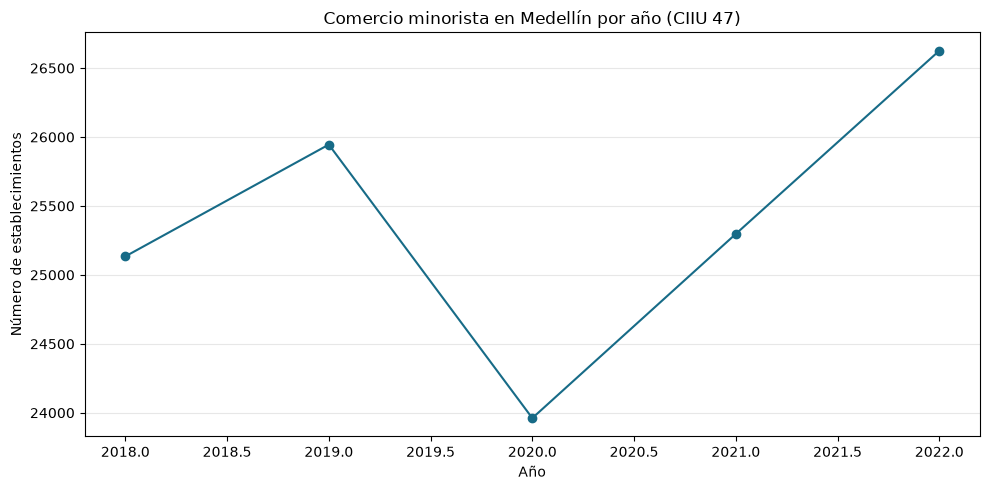

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

estructura_path = next((PROJECT_DIR / 'data' / 'raw').glob('Estructura*.csv'))
estructura = pd.read_csv(estructura_path, encoding='utf-8', sep=None, engine='python')

col_year, col_division, col_description = estructura.columns[:3]
value_columns = list(estructura.columns[3:])

minorista = estructura[
    estructura[col_division].astype(str).str.strip().eq('47')
].copy()

for column in value_columns:
    minorista[column] = pd.to_numeric(
        minorista[column].astype(str).str.replace(',', '', regex=False),
        errors='coerce',
    ).fillna(0)

serie_minorista = (
    minorista.assign(comercio_minorista=minorista[value_columns].sum(axis=1))
    [[col_year, 'comercio_minorista']]
    .rename(columns={col_year: 'año'})
    .sort_values('año')
    .reset_index(drop=True)
)

print(f'Fuente: {estructura_path.name}')
display(serie_minorista)

ax = serie_minorista.plot(
    x='año',
    y='comercio_minorista',
    kind='line',
    marker='o',
    figsize=(10, 5),
    legend=False,
    color='#176b87',
)
ax.set_title('Comercio minorista en Medellín por año (CIIU 47)')
ax.set_xlabel('Año')
ax.set_ylabel('Número de establecimientos')
ax.grid(axis='y', alpha=0.3)
ax.get_figure().tight_layout()
plt.show()

## 5. Exploración del anexo EMICRON: tiendas y panaderías

Aunque el archivo está identificado como EMICRON 2024, sus cuadros comparativos contienen estimaciones para 2019-2024. El cuadro `B.2` desagrega panaderías y actividades de comercio minorista. Es una encuesta de micronegocios y sus resultados son estimaciones nacionales expandidas, no un censo de establecimientos.

In [3]:
import re

emicron_matches = []
for sheet_name in SHEETS:
    sheet = pd.read_excel(
        FILE_PATH,
        sheet_name=sheet_name,
        header=None,
        engine='pyxlsb',
    )
    for row_number, row in sheet.iterrows():
        row_text = ' | '.join(row.dropna().astype(str))
        if re.search(r'tienda|panader', row_text, flags=re.IGNORECASE):
            emicron_matches.append({
                'hoja': sheet_name,
                'fila': row_number + 1,
                'contenido': row_text,
            })

emicron_matches_df = pd.DataFrame(emicron_matches)
print('Hojas y filas del anexo EMICRON 2024 que mencionan tiendas o panaderías:')
display(emicron_matches_df)
print('\nInterpretación: estas tablas corresponden a 2024; para construir una serie anual se requieren anexos EMICRON equivalentes de otros años.')

Hojas y filas del anexo EMICRON 2024 que mencionan tiendas o panaderías:


,hoja,fila,contenido
0,Índice,10,Cuadro 1. Cantidad y distribución de micronego...
1,Índice,11,Cuadro 2.Cantidad y distribución de micronegoc...
2,Índice,12,Cuadro 3. Cantidad y distribución de micronego...
3,Índice,13,Cuadro 4. Cantidad y distribución de micronego...
4,Índice,14,Cuadro 5. Cantidad y distribución de micronego...
...,...,...,...
168,H.9,6,ENCUESTA DE MICRONEGOCIOS -PANADERÍAS Y TIENDA...
169,H.9,11,Cantidad de micronegocios- panaderías y tienda...
170,H.9,26,Porcentaje de micronegocios- panaderías y tien...
171,J.1,6,ENCUESTA DE MICRONEGOCIOS -PANADERÍAS Y TIENDA...



Interpretación: estas tablas corresponden a 2024; para construir una serie anual se requieren anexos EMICRON equivalentes de otros años.


In [ ]:
SHEET_EMICRON_RELEVANT = 'B.2'

emicron_relevant = pd.read_excel(
    FILE_PATH,
    sheet_name=SHEET_EMICRON_RELEVANT,
    header=None,
    engine='pyxlsb',
)

print(f'Cuadro seleccionado: {SHEET_EMICRON_RELEVANT}')
display(emicron_relevant.iloc[10:23, :18])
print('\nEste cuadro contiene una serie comparable de 2019 a 2024 y desagrega panaderías y actividades de comercio minorista.')

Contenido completo de la hoja 'H.9' del anexo EMICRON 2024:


,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,ENCUESTA DE MICRONEGOCIOS -PANADERÍAS Y TIENDA...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Total Nacional,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Cuadro H.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


EMICRON: estimación de micronegocios por actividad económica


,año,panaderías,comercio_minorista_b2
0,2019,45132,523665
1,2020,28000,463826
2,2021,30528,518644
3,2022,33779,516620
4,2023,36926,491652
5,2024,37902,483540


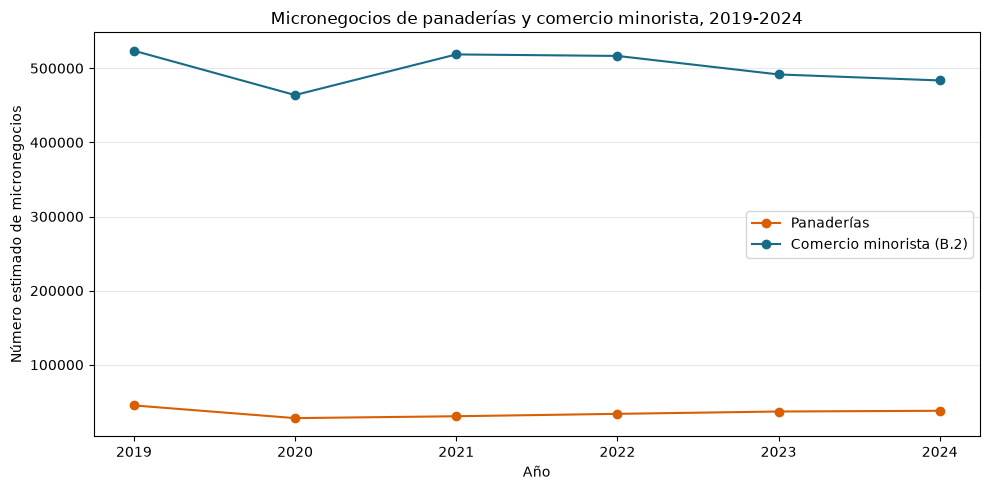

In [7]:
cuadro_b2 = pd.read_excel(
    FILE_PATH,
    sheet_name='B.2',
    header=None,
    engine='pyxlsb',
)

header_candidates = cuadro_b2.apply(
    lambda row: set(row.dropna().astype(str).str.replace('.0', '', regex=False)),
    axis=1,
)
year_row = header_candidates[
    header_candidates.apply(lambda values: {'2019', '2020'}.issubset(values))
].index[0]
data_start = year_row + 1

year_columns = {
    int(float(value)): column
    for column, value in enumerate(cuadro_b2.iloc[year_row])
    if pd.notna(value)
    and str(value).replace('.0', '').isdigit()
    and 2019 <= int(float(value)) <= 2024
}

data_rows = cuadro_b2.iloc[data_start:].copy()
data_rows = data_rows[
    data_rows.iloc[:, 0].notna()
    & ~data_rows.iloc[:, 0].astype(str).str.startswith('Cuadro')
]

panaderia_rows = data_rows[
    data_rows.iloc[:, 0].astype(str).str.contains(
        'productos de panadería', case=False, na=False
    )
]
minorista_rows = data_rows[
    data_rows.iloc[:, 0].astype(str).str.startswith('Comercio al por menor')
]

emicron_serie = pd.DataFrame({
    'año': sorted(year_columns),
    'panaderías': [
        pd.to_numeric(panaderia_rows.iloc[:, year_columns[year]].iloc[0], errors='coerce')
        for year in sorted(year_columns)
    ],
    'comercio_minorista_b2': [
        pd.to_numeric(minorista_rows.iloc[:, year_columns[year]], errors='coerce').sum()
        for year in sorted(year_columns)
    ],
})

emicron_serie['panaderías'] = emicron_serie['panaderías'].round(0).astype('Int64')
emicron_serie['comercio_minorista_b2'] = (
    emicron_serie['comercio_minorista_b2'].round(0).astype('Int64')
)

print('EMICRON: estimación de micronegocios por actividad económica')
display(emicron_serie)

ax = emicron_serie.plot(
    x='año',
    y=['panaderías', 'comercio_minorista_b2'],
    kind='line',
    marker='o',
    figsize=(10, 5),
    color=['#d95f02', '#176b87'],
)
ax.set_title('Micronegocios de panaderías y comercio minorista, 2019-2024')
ax.set_xlabel('Año')
ax.set_ylabel('Número estimado de micronegocios')
ax.legend(['Panaderías', 'Comercio minorista (B.2)'])
ax.grid(axis='y', alpha=0.3)
ax.get_figure().tight_layout()
plt.show()

## 6. Serie conjunta: panaderías y comercio minorista

Se suman las dos categorías del cuadro `B.2` porque comparten cobertura, metodología y periodo. El resultado representa el total estimado de micronegocios de estas actividades, no exclusivamente tiendas de barrio.

EMICRON: panaderías más comercio minorista


,año,panaderias_mas_comercio_minorista
0,2019,568797
1,2020,491826
2,2021,549172
3,2022,550399
4,2023,528578
5,2024,521442


Variación entre 2019 y 2024: -8.33%


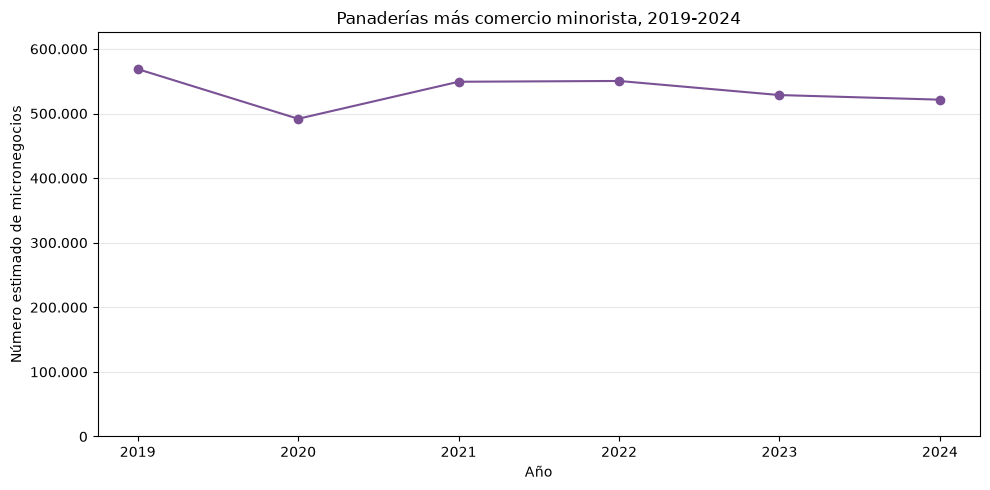

In [9]:
emicron_serie['panaderias_mas_comercio_minorista'] = (
    emicron_serie['panaderías'] + emicron_serie['comercio_minorista_b2']
)

variacion_conjunta = (
    (emicron_serie['panaderias_mas_comercio_minorista'].iloc[-1]
     - emicron_serie['panaderias_mas_comercio_minorista'].iloc[0])
    / emicron_serie['panaderias_mas_comercio_minorista'].iloc[0]
    * 100
)

print('EMICRON: panaderías más comercio minorista')
display(emicron_serie[['año', 'panaderias_mas_comercio_minorista']])
print(f'Variación entre 2019 y 2024: {variacion_conjunta:.2f}%')

ax = emicron_serie.plot(
    x='año',
    y='panaderias_mas_comercio_minorista',
    kind='line',
    marker='o',
    figsize=(10, 5),
    legend=False,
    color='#7a5195',
)
ax.set_title('Panaderías más comercio minorista, 2019-2024')
ax.set_xlabel('Año')
ax.set_ylabel('Número estimado de micronegocios')
ax.set_ylim(0, emicron_serie['panaderias_mas_comercio_minorista'].max() * 1.1)
ax.yaxis.set_major_formatter(lambda value, position: f'{value:,.0f}'.replace(',', '.'))
ax.grid(axis='y', alpha=0.3)
ax.get_figure().tight_layout()
plt.show()